# **Coffee Shop** | 11042025
---
`Copyright @ 2025. SMK Negeri 8 Malang. All rights reserved.`
- Lovi Adiva Alexandria
- Maulana El Jauziyah Al-Ghani

# **I. Data Understanding**

## ***A. Penjabaran Studi Kasus***

Kopi merupakan minuman yang memiliki banyak penggemar. Ada yang meminum kopi karena estetikanya, manfaatnya, untuk memulai hari, bahkan hanya sekedar ikut ikut saja. Nah kali ini di studi machine learning hari ini kita akan mencoba untuk memprediksi penghasilan dari suatu coffee shop berdasarkan kondisi kondisi pada coffee shop tersebut.

Harapannya nanti kita bisa mengetahui apa faktor yang bisa jadi mempengaruhi suksesnya suatu coffee shop

## ***B. Import Libraries***

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## ***C. Import Dataset***

In [2]:
dataset = pd.read_csv("coffee_shop_revenue.csv")
dataset

,Number_of_Customers_Per_Day,Average_Order_Value,Operating_Hours_Per_Day,Number_of_Employees,Marketing_Spend_Per_Day,Location_Foot_Traffic,Daily_Revenue
0,152,6.74,14,4,106.62,97,1547.81
1,485,4.50,12,8,57.83,744,2084.68
2,398,9.09,6,6,91.76,636,3118.39
3,320,8.48,17,4,462.63,770,2912.20
4,156,7.44,17,2,412.52,232,1663.42
...,...,...,...,...,...,...,...
1995,372,6.41,11,4,466.11,913,2816.85
1996,105,3.01,11,7,12.62,235,337.97
1997,89,5.28,16,9,376.64,310,951.34
1998,403,9.41,7,12,452.49,577,4266.21


# **II. Data Preparation**

## ***A. Exploratory Data Analysis***

### 1. Inspeksi Daftar Variabel

In [3]:
dataset.columns

Index(['Number_of_Customers_Per_Day', 'Average_Order_Value',
       'Operating_Hours_Per_Day', 'Number_of_Employees',
       'Marketing_Spend_Per_Day', 'Location_Foot_Traffic', 'Daily_Revenue'],
      dtype='object')

Kami melihat bentuk atau karakteristik value dari setiap fitur dan mampu mengidentifikasi jenis data setiap fitur antara lain:

Target: `Daily_Revenue`

Numerik Continu:  `Average_Order_Value`, `Marketing_Spend_Per_Day`, `Location_Foot_Traffic`

Numerik Diskrit: `Number_of_Customers_Per_Day`, `Operating_Hours_Per_Day`, `Number_of_Employees`

Kategorikal Nominal: Tidak Ada

Kategorikal Ordinal: Tidak Ada

In [4]:
fitur_continu = ['Average_Order_Value', 'Marketing_Spend_Per_Day', 'Location_Foot_Traffic', 'Daily_Revenue']
fitur_diskrit = ['Number_of_Customers_Per_Day', 'Operating_Hours_Per_Day', 'Number_of_Employees', 'Daily_Revenue']

fitur_real = dataset.columns

### 2. Inspeksi Informasi Ringkas

In [5]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Number_of_Customers_Per_Day  2000 non-null   int64  
 1   Average_Order_Value          2000 non-null   float64
 2   Operating_Hours_Per_Day      2000 non-null   int64  
 3   Number_of_Employees          2000 non-null   int64  
 4   Marketing_Spend_Per_Day      2000 non-null   float64
 5   Location_Foot_Traffic        2000 non-null   int64  
 6   Daily_Revenue                2000 non-null   float64
dtypes: float64(3), int64(4)
memory usage: 109.5 KB


### 3. Inspeksi Statistik Deskriptif

In [6]:
dataset.describe()

,Number_of_Customers_Per_Day,Average_Order_Value,Operating_Hours_Per_Day,Number_of_Employees,Marketing_Spend_Per_Day,Location_Foot_Traffic,Daily_Revenue
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,274.296000,6.261215,11.667000,7.947000,252.614160,534.893500,1917.325940
std,129.441933,2.175832,3.438608,3.742218,141.136004,271.662295,976.202746
min,50.000000,2.500000,6.000000,2.000000,10.120000,50.000000,-58.950000
25%,164.000000,4.410000,9.000000,5.000000,130.125000,302.000000,1140.085000
50%,275.000000,6.300000,12.000000,8.000000,250.995000,540.000000,1770.775000
75%,386.000000,8.120000,15.000000,11.000000,375.352500,767.000000,2530.455000
max,499.000000,10.000000,17.000000,14.000000,499.740000,999.000000,5114.600000


### 4. Inspeksi Data NaN

In [7]:
dataset.isna().sum()

Number_of_Customers_Per_Day    0
Average_Order_Value            0
Operating_Hours_Per_Day        0
Number_of_Employees            0
Marketing_Spend_Per_Day        0
Location_Foot_Traffic          0
Daily_Revenue                  0
dtype: int64

### 5. Inspeksi Data Duplicated

In [8]:
dataset.duplicated().sum()

np.int64(0)

### 6. Dataset Sementara

In [9]:
dataset_copy = dataset.copy()

Membuat fitur revenue bulanan

In [10]:
dataset_copy['Revenue_Per_Month'] = dataset_copy['Daily_Revenue'] * 30

Membuat Fitur Biaya Market Bulanan

In [11]:
dataset_copy['Monthly_Marketing'] = dataset_copy['Marketing_Spend_Per_Day'] * 30

Membuat Fitur Clean Revenue

In [12]:
dataset_copy['Clean_Revenue'] = dataset_copy['Revenue_Per_Month'] - dataset_copy['Monthly_Marketing']

Mengencode Label

In [13]:
dataset['Target'] = dataset_copy['Clean_Revenue'].apply(lambda x: "Low" if x < 27048 else("Medium" if x < 43758 else "High"))
dataset_copy['Target'] = dataset_copy['Clean_Revenue'].apply(lambda x: "Low" if x < 27048 else("Medium" if x < 43758 else "High"))
map_target = {"Low" : 1, "Medium" : 2, "High" : 3}
dataset_copy['Target'] = dataset_copy['Target'].map(map_target)

In [14]:
dataset_copy['Target'].value_counts()

Target
3    1050
1     500
2     450
Name: count, dtype: int64

inspeksi ulang

In [15]:
dataset_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Number_of_Customers_Per_Day  2000 non-null   int64  
 1   Average_Order_Value          2000 non-null   float64
 2   Operating_Hours_Per_Day      2000 non-null   int64  
 3   Number_of_Employees          2000 non-null   int64  
 4   Marketing_Spend_Per_Day      2000 non-null   float64
 5   Location_Foot_Traffic        2000 non-null   int64  
 6   Daily_Revenue                2000 non-null   float64
 7   Revenue_Per_Month            2000 non-null   float64
 8   Monthly_Marketing            2000 non-null   float64
 9   Clean_Revenue                2000 non-null   float64
 10  Target                       2000 non-null   int64  
dtypes: float64(6), int64(5)
memory usage: 172.0 KB


In [16]:
dataset_copy.describe()

,Number_of_Customers_Per_Day,Average_Order_Value,Operating_Hours_Per_Day,Number_of_Employees,Marketing_Spend_Per_Day,Location_Foot_Traffic,Daily_Revenue,Revenue_Per_Month,Monthly_Marketing,Clean_Revenue,Target
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,274.296000,6.261215,11.667000,7.947000,252.614160,534.893500,1917.325940,57519.778200,7578.424800,49941.353400,2.275000
std,129.441933,2.175832,3.438608,3.742218,141.136004,271.662295,976.202746,29286.082382,4234.080129,28502.785175,0.836496
min,50.000000,2.500000,6.000000,2.000000,10.120000,50.000000,-58.950000,-1768.500000,303.600000,-2256.300000,1.000000
25%,164.000000,4.410000,9.000000,5.000000,130.125000,302.000000,1140.085000,34202.550000,3903.750000,27048.900000,1.750000
50%,275.000000,6.300000,12.000000,8.000000,250.995000,540.000000,1770.775000,53123.250000,7529.850000,45943.350000,3.000000
75%,386.000000,8.120000,15.000000,11.000000,375.352500,767.000000,2530.455000,75913.650000,11260.575000,67807.800000,3.000000
max,499.000000,10.000000,17.000000,14.000000,499.740000,999.000000,5114.600000,153438.000000,14992.200000,139188.900000,3.000000


### 7. Inspeksi Rentang Data

In [17]:
def check_range(dataset, col):
    for cols in col:

        Q1 = dataset[cols].quantile(0.25)
        Q3 = dataset[cols].quantile(0.75)
        IQR = Q3 - Q1

        print(f"Kolom: {cols}")
        print(f"Q1: {Q1}")
        print(f"IQR: {IQR}")
        print(f"Q3: {Q3}\n")

check_range(dataset_copy, dataset_copy.columns)

Kolom: Number_of_Customers_Per_Day
Q1: 164.0
IQR: 222.0
Q3: 386.0

Kolom: Average_Order_Value
Q1: 4.41
IQR: 3.709999999999999
Q3: 8.12

Kolom: Operating_Hours_Per_Day
Q1: 9.0
IQR: 6.0
Q3: 15.0

Kolom: Number_of_Employees
Q1: 5.0
IQR: 6.0
Q3: 11.0

Kolom: Marketing_Spend_Per_Day
Q1: 130.125
IQR: 245.22750000000002
Q3: 375.3525

Kolom: Location_Foot_Traffic
Q1: 302.0
IQR: 465.0
Q3: 767.0

Kolom: Daily_Revenue
Q1: 1140.085
IQR: 1390.37
Q3: 2530.455

Kolom: Revenue_Per_Month
Q1: 34202.55
IQR: 41711.09999999999
Q3: 75913.65

Kolom: Monthly_Marketing
Q1: 3903.75
IQR: 7356.825000000001
Q3: 11260.575

Kolom: Clean_Revenue
Q1: 27048.9
IQR: 40758.89999999999
Q3: 67807.79999999999

Kolom: Target
Q1: 1.75
IQR: 1.25
Q3: 3.0



### 7. Univariate Analysis

#### *a. Inspeksi Distribusi Kelas Target*

In [18]:
target_counts = dataset["Target"].value_counts()
target_counts

Target
High      1050
Low        500
Medium     450
Name: count, dtype: int64

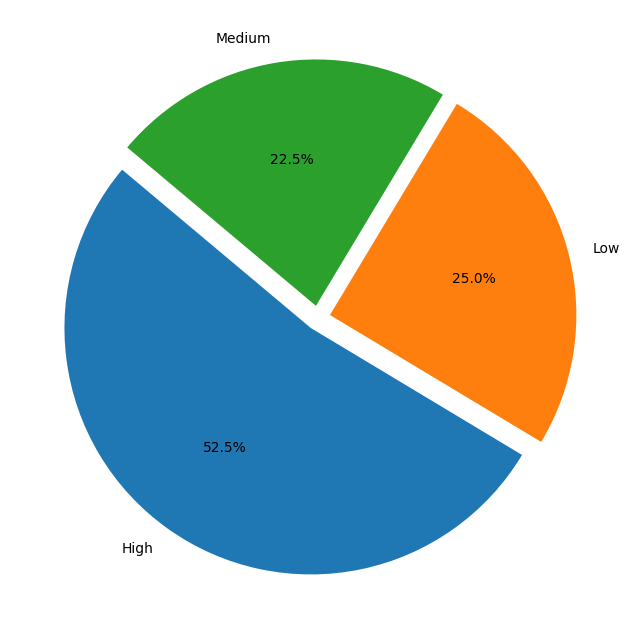

In [19]:
explodes = [0.05] * len(target_counts)
color = plt.get_cmap('tab10').colors

plt.figure(figsize=(8, 8))
plt.pie(
    target_counts,
    labels =target_counts.index,
    explode=explodes,
    colors=color,
    autopct="%1.1f%%",
    startangle=140
)
plt.show()

### 8. Bivariate Analysis

#### *a. Inspeksi Distribusi Fitur dengan Target*

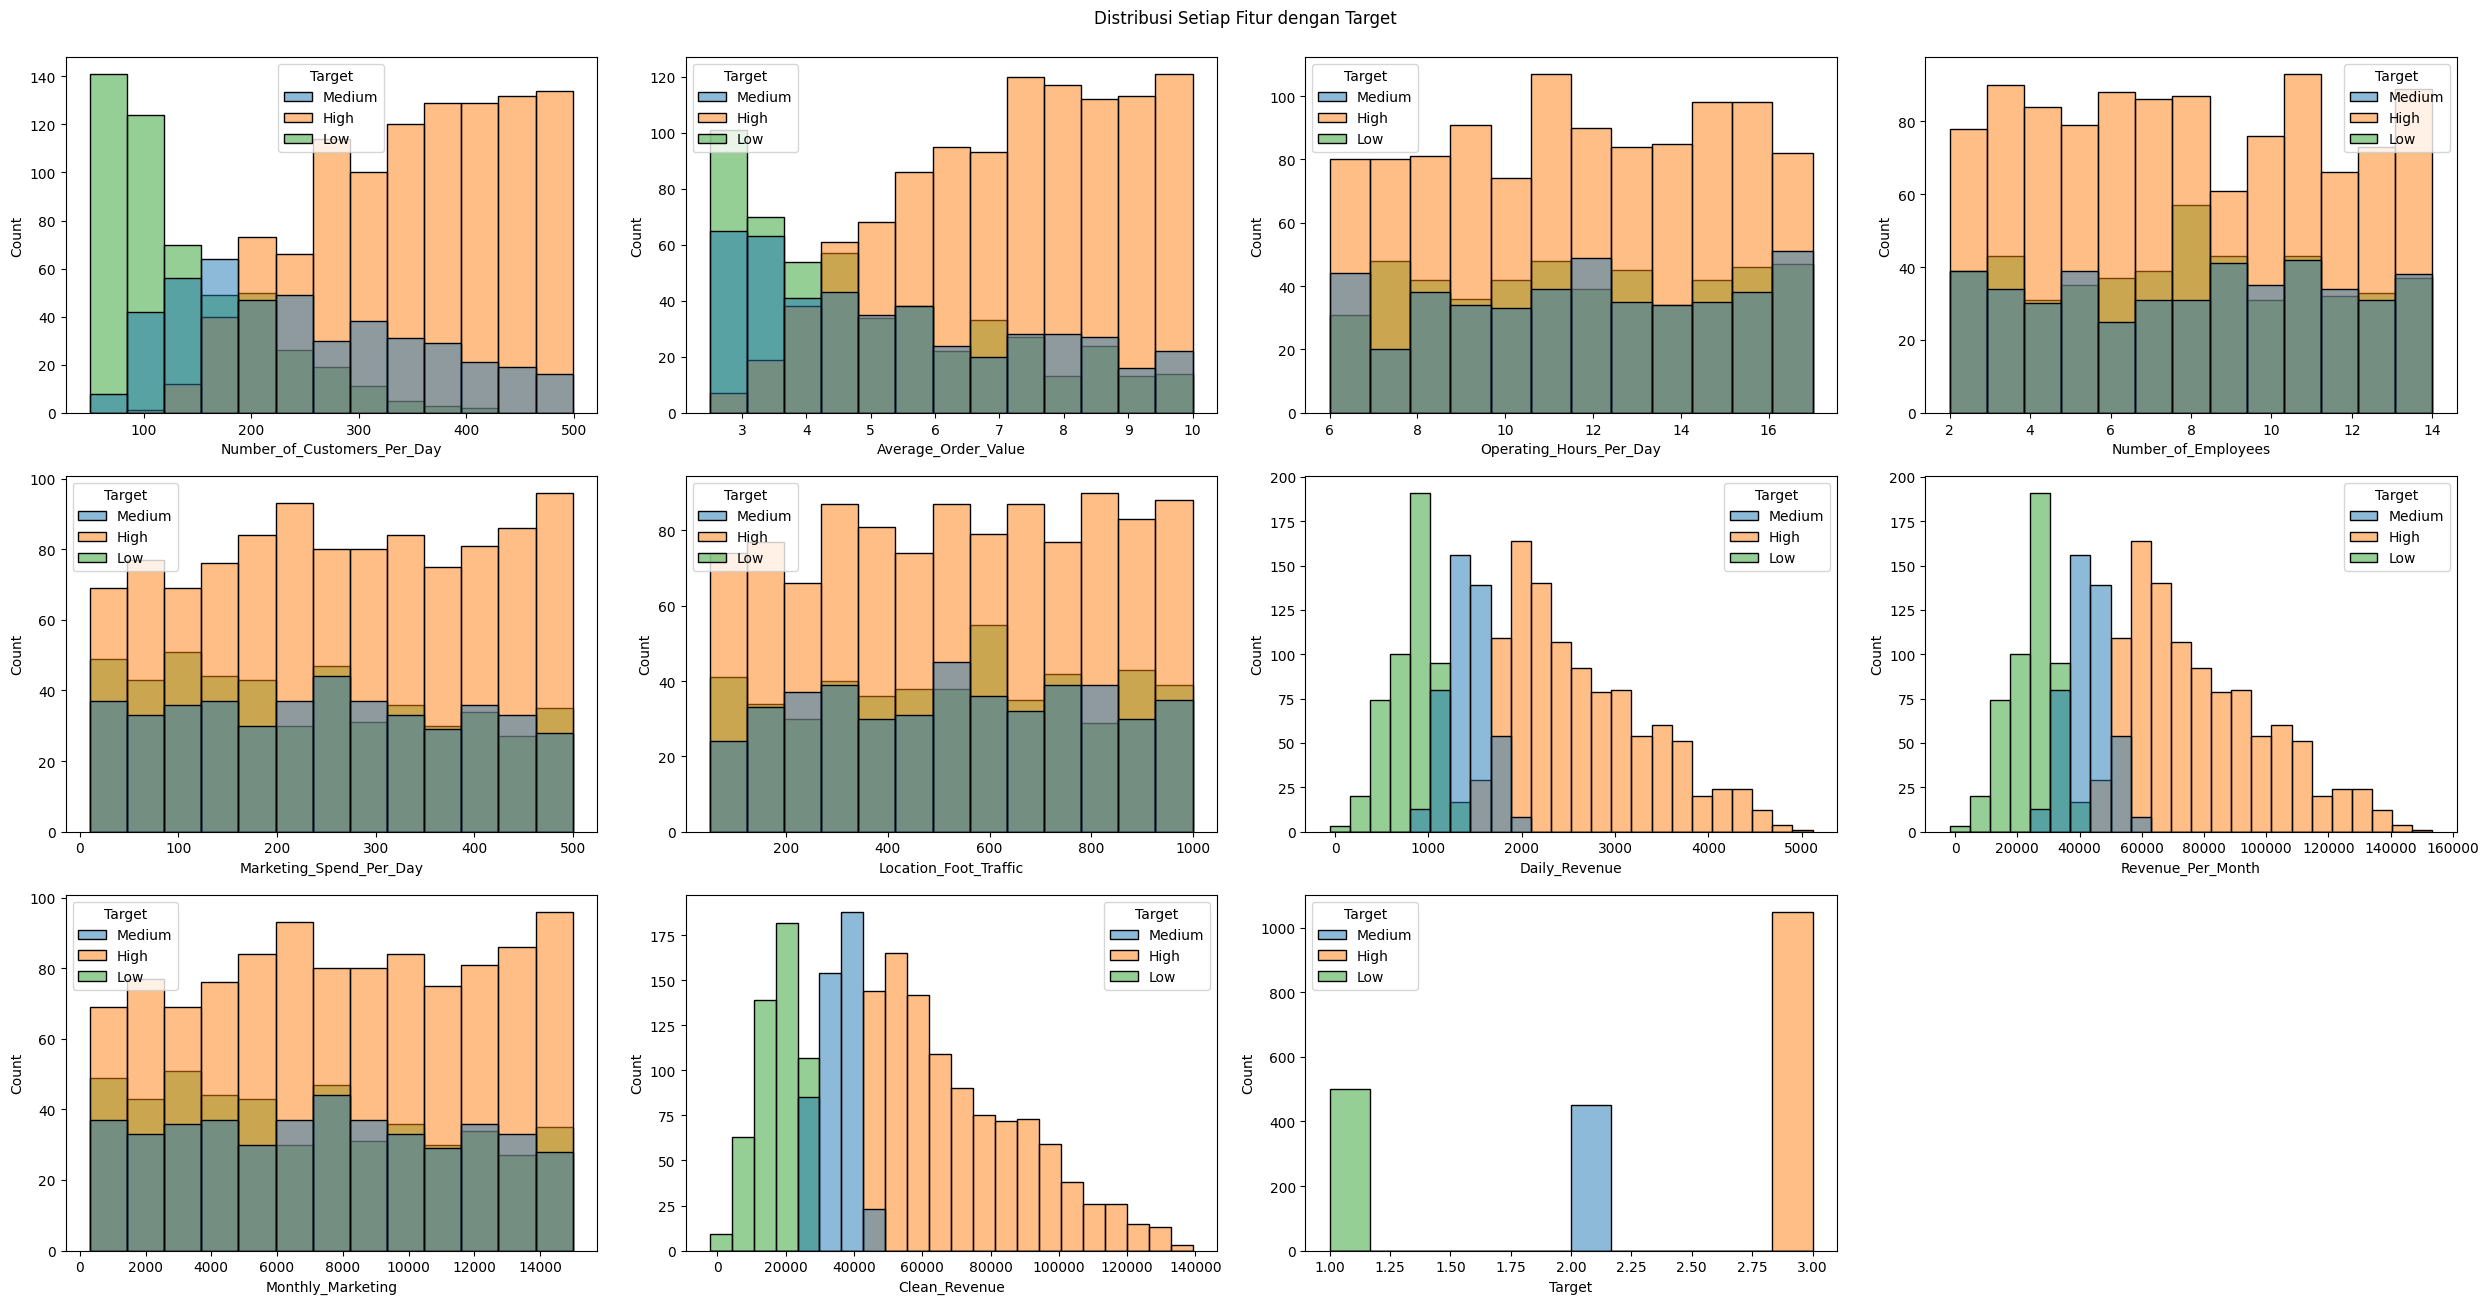

In [20]:
plt.figure(figsize=(25, 13))
for i, col in enumerate(dataset_copy):
    plt.subplot(3, 4, i+1)
    sns.histplot(x=dataset_copy[col], hue=dataset["Target"])

plt.suptitle("Distribusi Setiap Fitur dengan Target", y=1)
plt.tight_layout()
plt.show()

### 9. Multivariate Analysis

#### *a. Inspeksi Distribusi Data dengan Target*

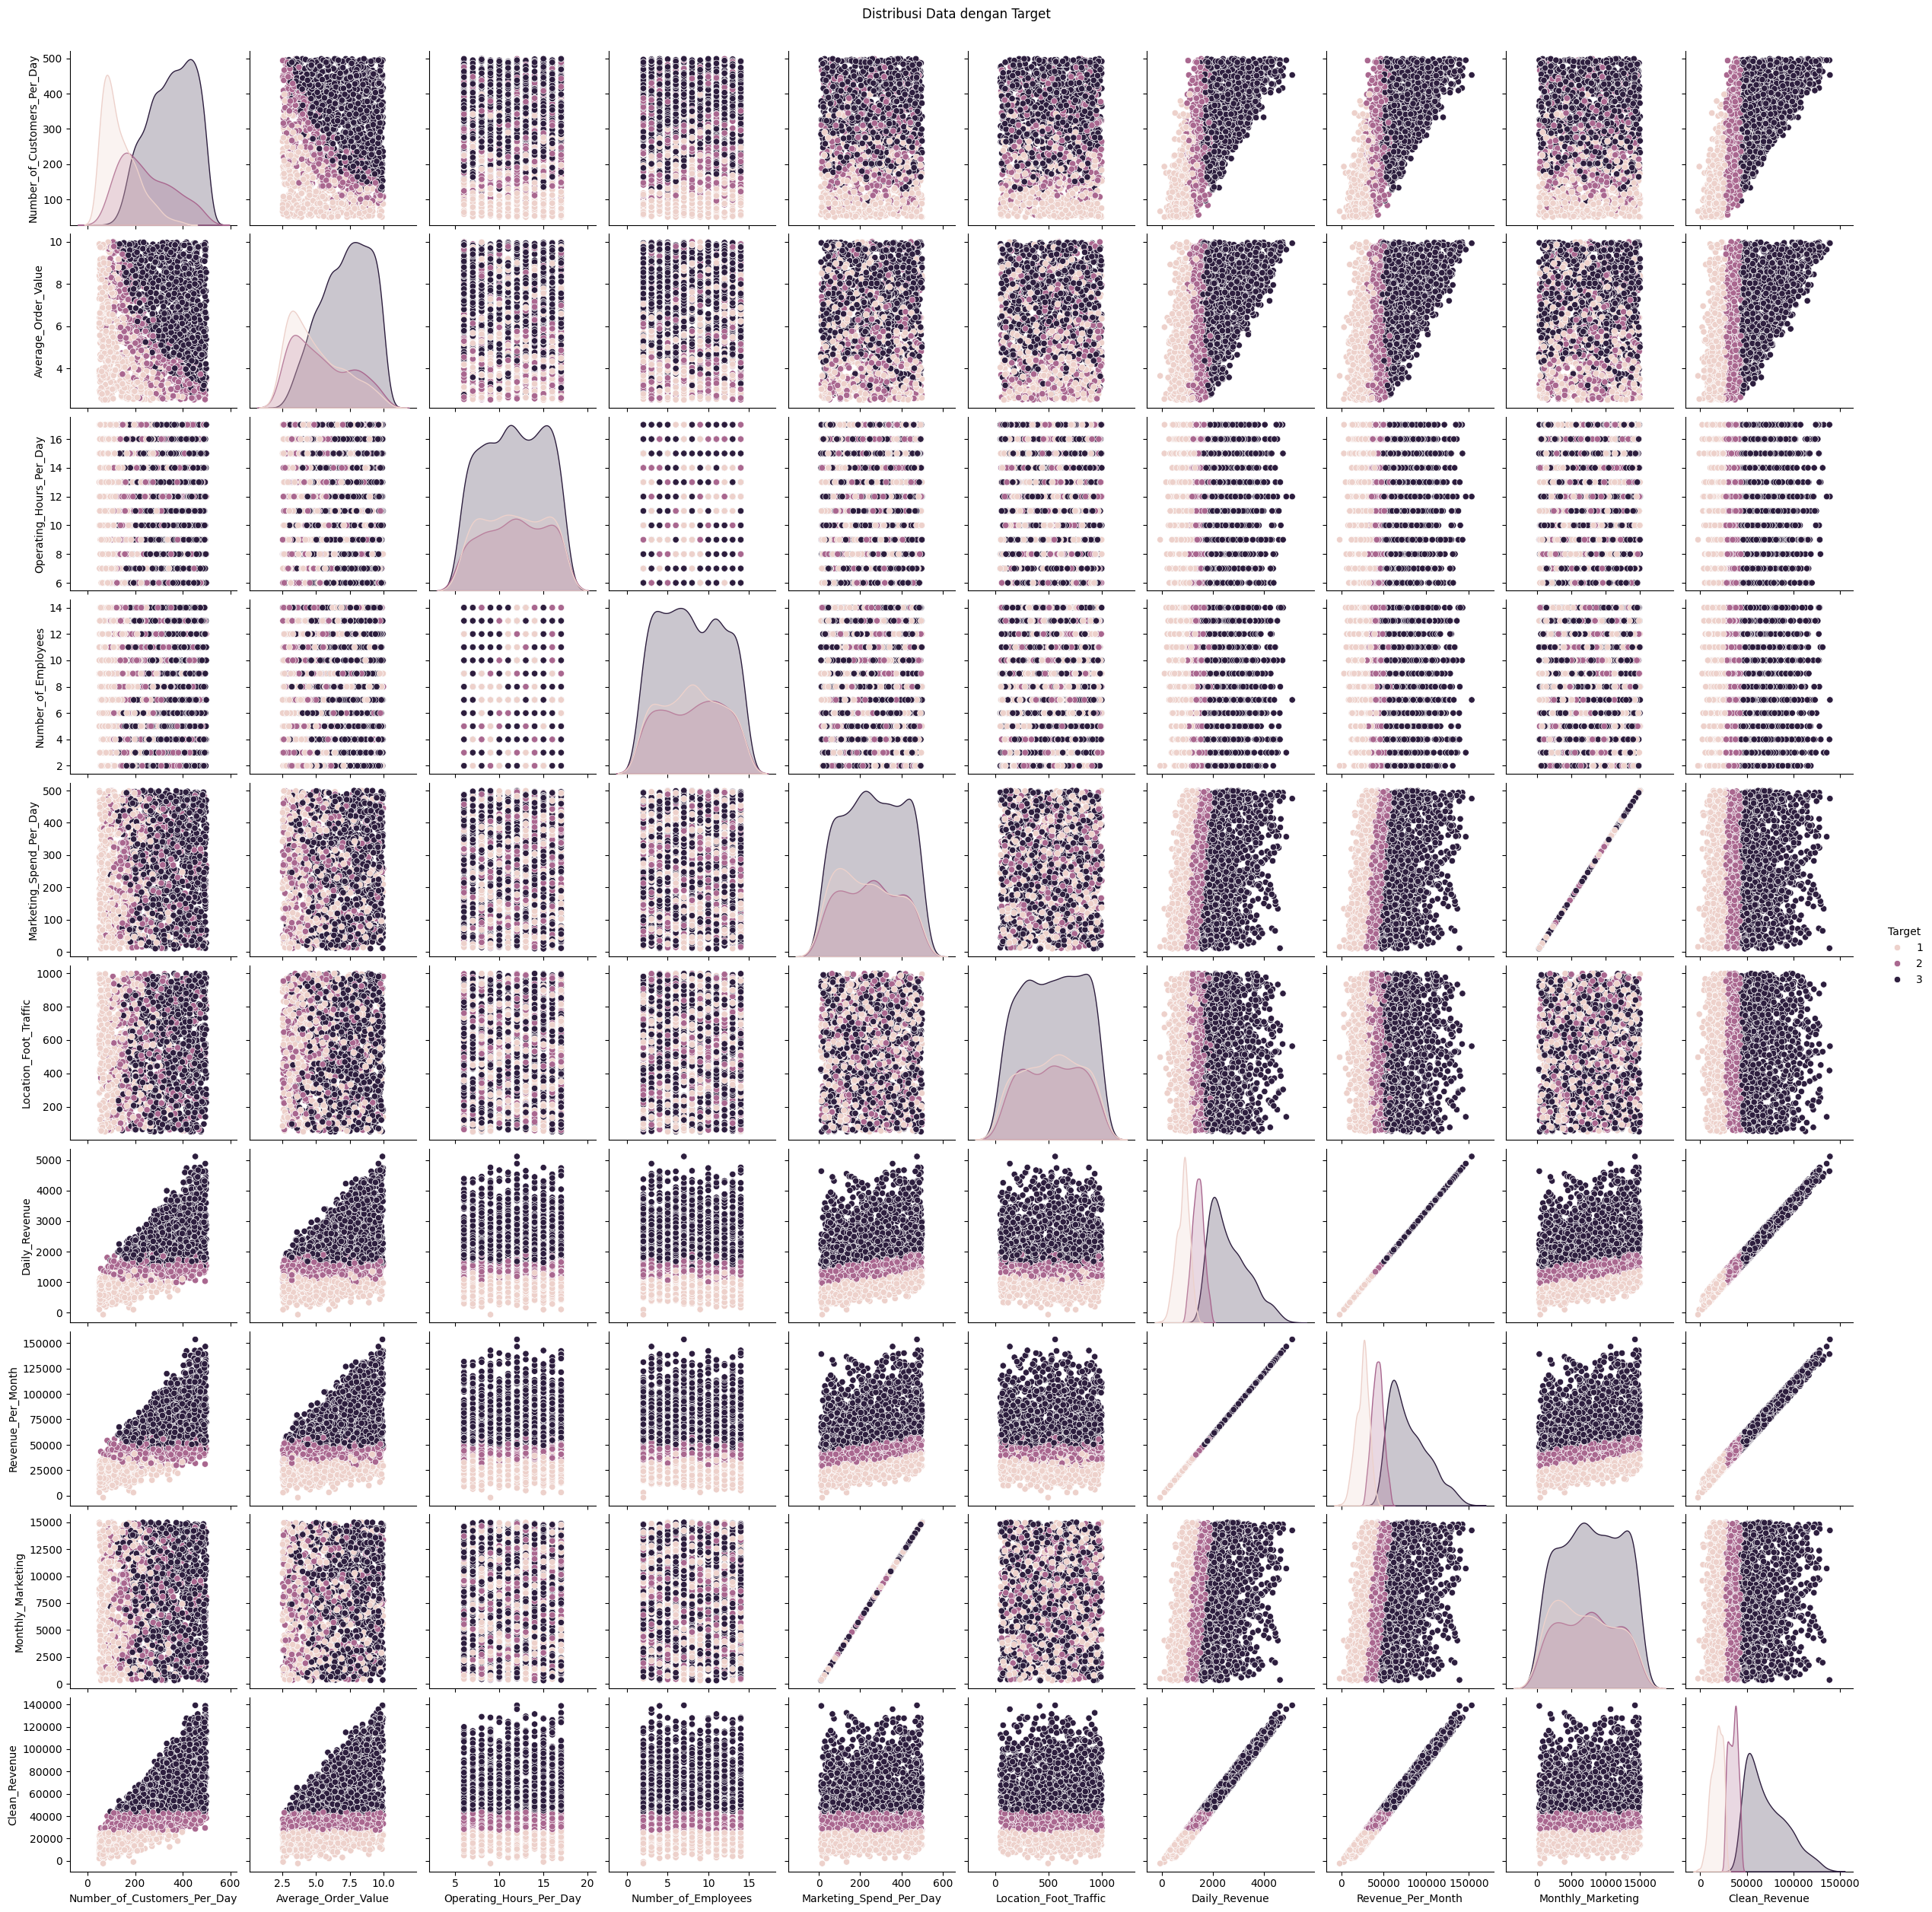

In [21]:
sns.pairplot(data=dataset_copy, hue="Target")
plt.suptitle("Distribusi Data dengan Target", y=1.01)
plt.show()

### 10. Inspeksi Korelasi

#### *a. Mutual Information*

In [22]:
real_feature = ["Number_of_Customers_Per_Day", "Average_Order_Value", "Operating_Hours_Per_Day", "Number_of_Employees", "Marketing_Spend_Per_Day", "Location_Foot_Traffic"]

def probability_distribution(x):
    unique, counts = np.unique(x, return_counts=True)
    return counts / counts.sum()

def calculate_entropy(x):
    probs = probability_distribution(x)
    return -np.sum(probs * np.log2(probs + 1e-10))

def mutual_information(x, y):
    xy_pairs = list(zip(x, y))
    unqiue_xy, counts_xy = np.unique(xy_pairs, return_counts=True)
    probs_xy = counts_xy / counts_xy.sum()
    entropy_xy = -np.sum(probs_xy * np.log2(probs_xy + 1e-10))

    entropy_x = calculate_entropy(x)
    entropy_y = calculate_entropy(y)
    return entropy_x + entropy_y - entropy_xy

fitur = dataset_copy[real_feature]
target = dataset_copy["Target"]

mi_scores = {col: mutual_information(fitur[col].values, target.values) for col in fitur.columns}
mi_df = pd.DataFrame(list(mi_scores.items()), columns=["Feature", "Mutual Information"])
mi_df = mi_df.sort_values(by="Mutual Information", ascending=False)
mi_df

,Feature,Mutual Information
4,Marketing_Spend_Per_Day,5.202515
5,Location_Foot_Traffic,4.477032
1,Average_Order_Value,4.369271
0,Number_of_Customers_Per_Day,4.040889
3,Number_of_Employees,1.883744
2,Operating_Hours_Per_Day,1.526014


C:\Users\nizam\AppData\Local\Temp\ipykernel_17832\643596418.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mi_df, x="Mutual Information", y="Feature", palette="viridis")


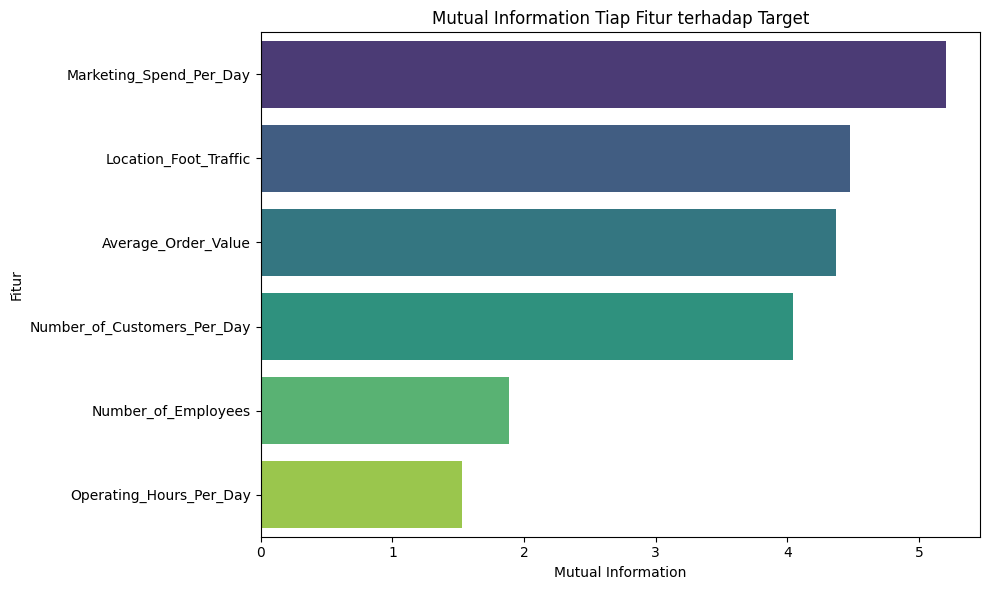

In [23]:
plt.figure(figsize=(10, 6))
sns.barplot(data=mi_df, x="Mutual Information", y="Feature", palette="viridis")

plt.title("Mutual Information Tiap Fitur terhadap Target")
plt.xlabel("Mutual Information")
plt.ylabel("Fitur")
plt.tight_layout()
plt.show()

#### *b. Kendall Method*

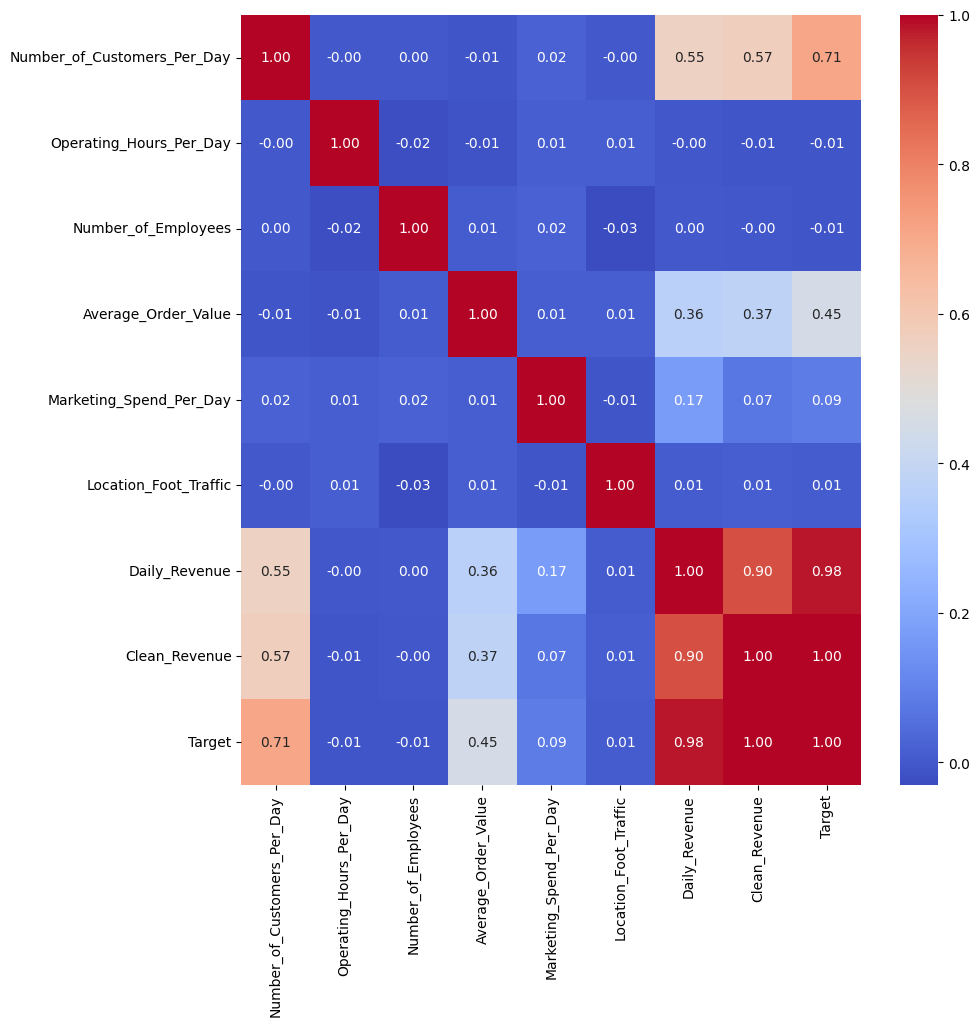

In [24]:
def kendall_method(x, y):
    n = len(x)
    concordant = 0
    disconcordant = 0

    for i in range(n - 1 ):
        for j in range(i + 1, n):

            x_diff = x[i] - x[j]
            y_diff = y[i] - y[j]

            if x_diff * y_diff > 0:
                concordant += 1
            elif x_diff * y_diff < 0:
                disconcordant += 1
    
    if (concordant - disconcordant) == 0:
        return 0
    
    return (concordant - disconcordant) / (concordant + disconcordant)

fitur_continu_real = ['Number_of_Customers_Per_Day', 'Operating_Hours_Per_Day', 'Number_of_Employees', 'Average_Order_Value', 'Marketing_Spend_Per_Day', 'Location_Foot_Traffic', 'Daily_Revenue', "Clean_Revenue","Target"]
corr_matrix = pd.DataFrame(index=fitur_continu_real, columns=fitur_continu_real)

for col1 in fitur_continu_real:
    for col2 in fitur_continu_real:
        corr_matrix.loc[col1, col2] = kendall_method(dataset_copy[col1].values, dataset_copy[col2].values)

corr_matrix = corr_matrix.astype(float)

plt.figure(figsize=(10,10))
sns.heatmap(corr_matrix, annot = True, fmt=".2f", cmap = "coolwarm")
plt.show()

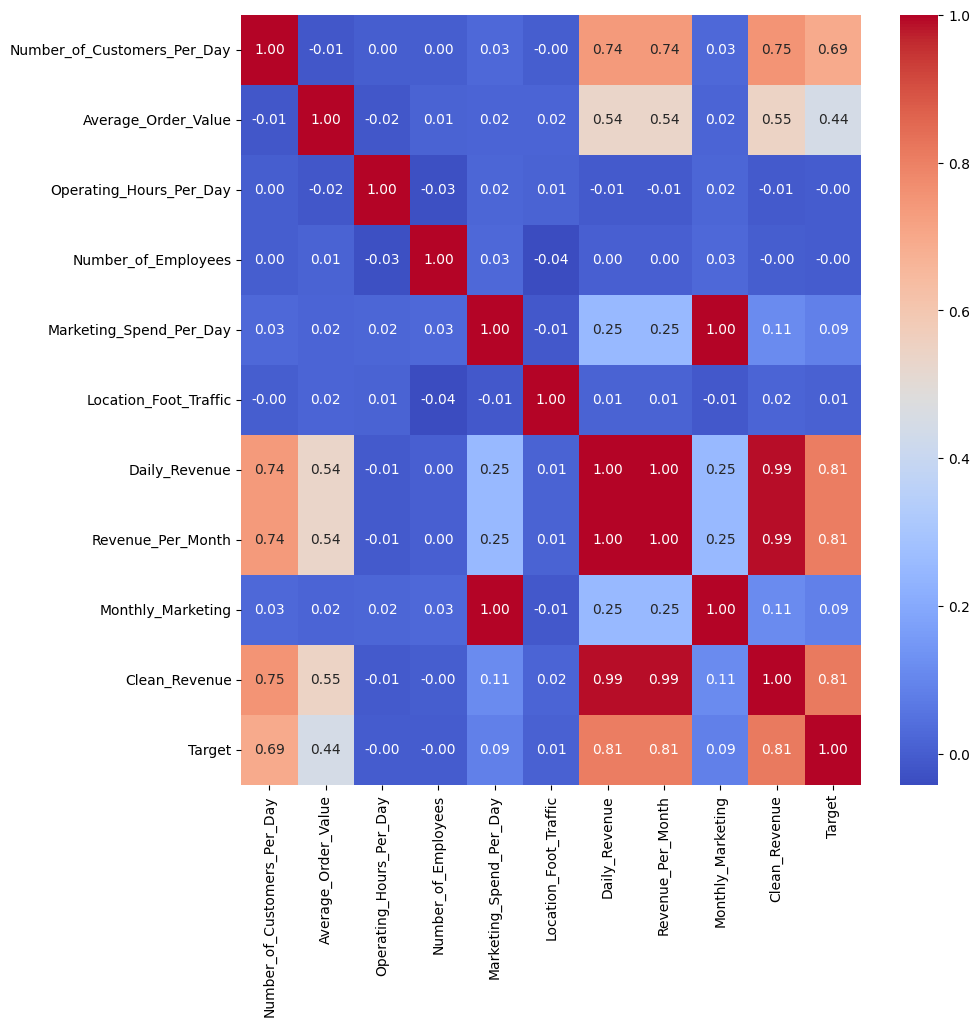

In [77]:
plt.figure(figsize=(10,10))
sns.heatmap(dataset_copy.corr(), annot = True, fmt=".2f", cmap = "coolwarm")
plt.show()

#### *c. Chi-square Method*

In [25]:
def chi_square_test(data, col1, col2):
    observed = pd.crosstab(data[col1], data[col2])

    total = observed.values.sum()
    row_totals = observed.sum(axis=1).values.reshape(-1, 1)
    col_totals = observed.sum(axis=0).values.reshape(1, -1)

    expected = row_totals @ col_totals / total
    chi_square = ((observed.values - expected) ** 2 / expected).sum()
    dof = (observed.shape[0] - 1) * (observed.shape[1] - 1)


    print(f"Feature: {col1} | Chi-square Score: {chi_square:.4f}")

    return chi_square, dof

chi_scores = []

fitur_diskrit =[ 'Number_of_Customers_Per_Day', 'Operating_Hours_Per_Day', 'Number_of_Employees', 'Daily_Revenue', "Target"]

for col in fitur_diskrit:
    chi, dof = chi_square_test(dataset_copy, col, 'Target')
    chi_scores.append((col, chi))

chi_df = pd.DataFrame(chi_scores, columns=["Feature", "Chi-Square Score"])
chi_df = chi_df.sort_values(by="Chi-Square Score", ascending=False)

Feature: Number_of_Customers_Per_Day | Chi-square Score: 1839.2211
Feature: Operating_Hours_Per_Day | Chi-square Score: 25.4116
Feature: Number_of_Employees | Chi-square Score: 22.6920
Feature: Daily_Revenue | Chi-square Score: 3995.7778
Feature: Target | Chi-square Score: 4000.0000


C:\Users\nizam\AppData\Local\Temp\ipykernel_17832\3289514411.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=chi_df, x="Feature", y="Chi-Square Score", palette="magma")


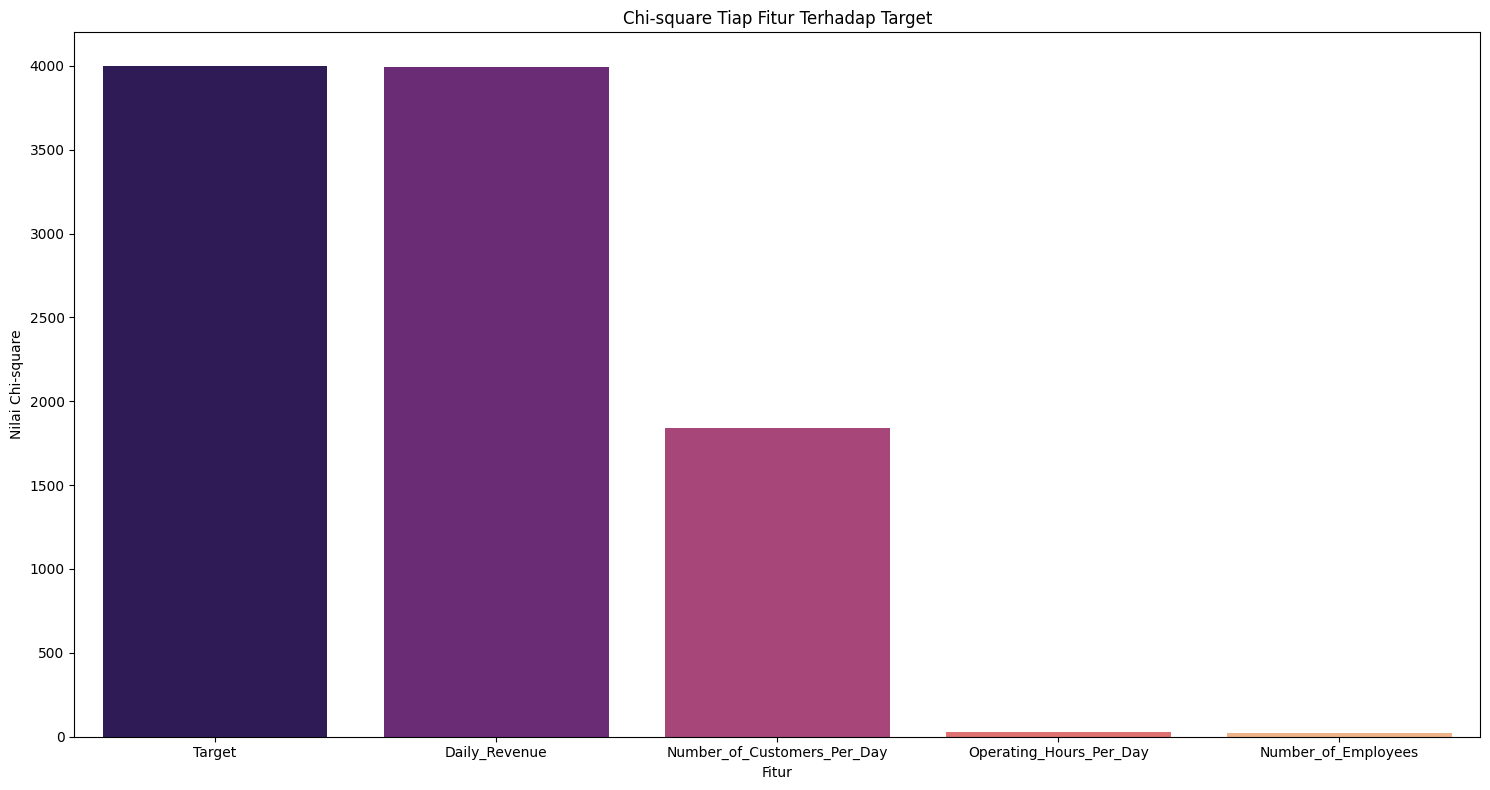

In [26]:
plt.figure(figsize=(15, 8))
sns.barplot(data=chi_df, x="Feature", y="Chi-Square Score", palette="magma")

plt.title("Chi-square Tiap Fitur Terhadap Target")
plt.xlabel("Fitur")
plt.ylabel("Nilai Chi-square")
plt.tight_layout()
plt.show()

### 11. Inspeksi Outlier

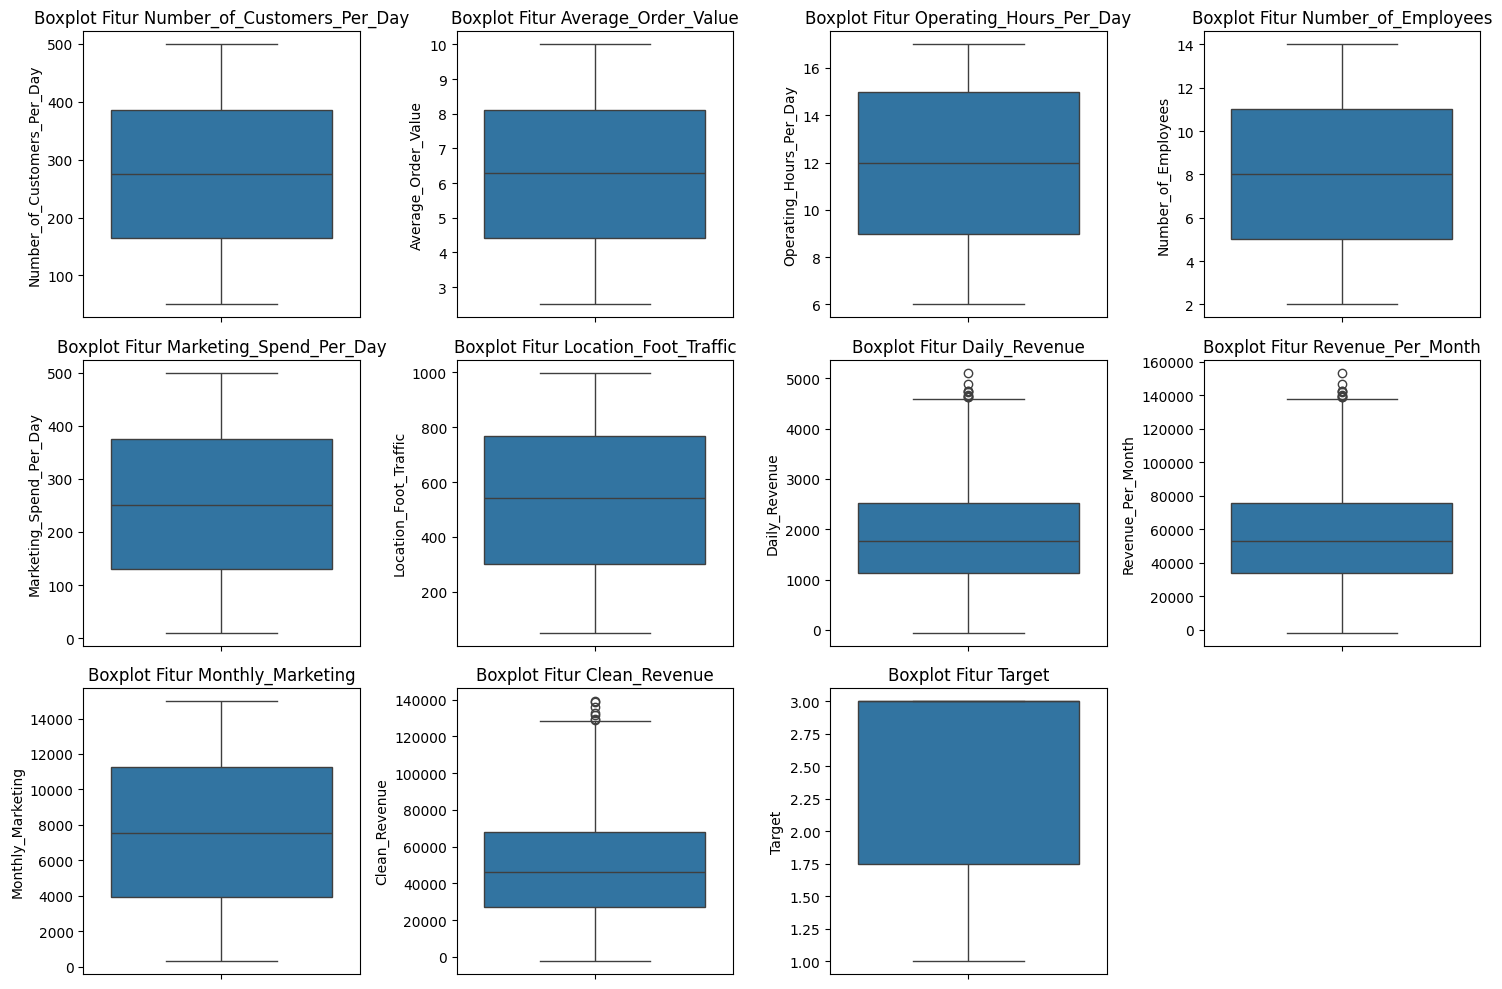

In [27]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(dataset_copy.select_dtypes(include=["number"]).columns):
    plt.subplot(3, 4, i+1)
    sns.boxplot(y=dataset_copy[col])
    plt.title(f"Boxplot Fitur {col}")

plt.tight_layout()
plt.show()

## ***B. Feature Selection***

1. Number_of_Customers_Per_Day
2. Average_Order_Value
3. Marketing_Spend_Per_Day
4. Daily Revenue

In [28]:
feature_cols = ['Number_of_Customers_Per_Day', 'Average_Order_Value', 'Marketing_Spend_Per_Day', 'Daily_Revenue']

Setelah melakukan proses analisis pada step EDA, kami dapat memberikan beberapa kesimpulan yang kami dapatkan:

1. Yang paling menentukan apakah suatu toko kopi ramai atau tidak itu berdasarkan berapa banyak rata rata customer yang datang perharinya

2. Faktor - Faktor lain yang mendukung revenue suatu coffee shop adalah berapa transaksi per-pelanggan, berapa budget marketing yang dikeluarkan, dan berapa revenue yang didapatkan perhari

3. Meskipun logis kalau misalnya semakin banyak budget yang dikeluarkan berarti semakin banyak customer, namun nyatanya fitur Marketing Spend tidak berkorelasi dengan customer

4. Penghasilan kotor tidak terlalu merubah penghasilan bersih

5. Semakin banyak revenue yang dihasilkan, maka pemilik toko kopi akan sedikit terdorong untuk menambah budget marketing

## ***C. Data Preprocessing***

In [29]:
# dataset['Revenue_Per_Month'] = dataset['Daily_Revenue'] * 30
# dataset['Monthly_Marketing'] = dataset['Marketing_Spend_Per_Day'] * 30
# dataset['Clean_Revenue'] = dataset['Revenue_Per_Month'] - dataset['Monthly_Marketing']

# dataset['Target'] = dataset['Clean_Revenue'].apply(lambda x: "Low" if x < 27048 else("Medium" if x < 43758 else "High"))
# map_target = {"Low" : 1, "Medium" : 2, "High" : 3}
dataset['Target'] = dataset['Target'].map(map_target)

## ***D. Splitting Dataset***

In [30]:
def stratified_split_data(dataset, target_column, training_size=0.8, random_state=42, frac=1):
    np.random.seed(random_state)
    train_list, test_list = [], []

    for class_value in dataset[target_column].unique():
        class_data = dataset[dataset[target_column] == class_value]
        class_data = class_data.sample(random_state=random_state, frac=frac)

        split_idx = int(len(class_data) * training_size)
        train_list.append(class_data.iloc[:split_idx])
        test_list.append(class_data[split_idx:])

    train_set = pd.concat(train_list).reset_index(drop=True)
    test_set = pd.concat(test_list).reset_index(drop=True)
    return train_set, test_set

dataset_training, dataset_testing = stratified_split_data(dataset, "Target")

## ***E. Data Oversampling***

In [31]:
dataset_training['Target'].value_counts()

Target
3    840
1    400
2    360
Name: count, dtype: int64

In [32]:
def apply_smote_manual(dataset, target_column, additional_size=None):
    classes = dataset[target_column].value_counts()
    resampled_data = [dataset]
    
    for label, size in classes.items():
        if additional_size and additional_size.get(label, 0) > 0:
            minority_class_data = dataset[dataset[target_column] == label]
            additional_samples = minority_class_data.sample(n=additional_size[label], replace=True, random_state=42)
            resampled_data.append(additional_samples)
    
    final_dataset = pd.concat(resampled_data).sample(frac=1, random_state=42).reset_index(drop=True)
    return final_dataset

additional_samples = {2: 40, 1:40}

dataset_training = apply_smote_manual(dataset_training, 'Target', additional_samples)

In [33]:
dataset_training['Target'].value_counts()

Target
3    840
1    440
2    400
Name: count, dtype: int64

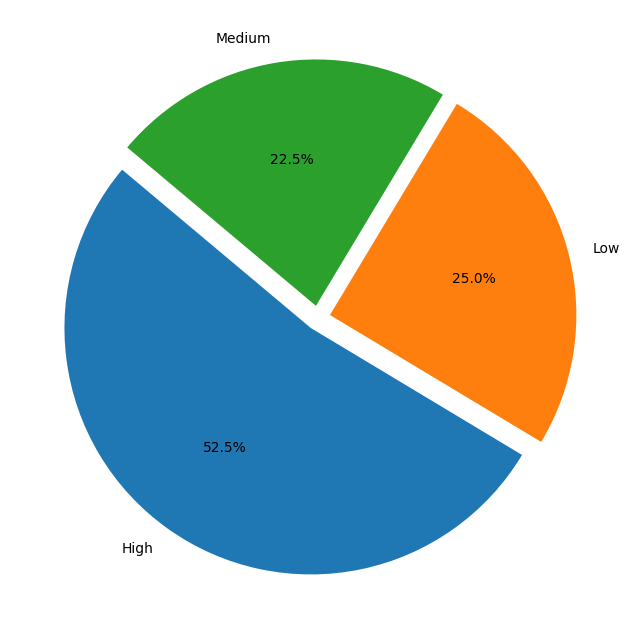

In [34]:
explodes = [0.05] * len(target_counts)
color = plt.get_cmap('tab10').colors

plt.figure(figsize=(8, 8))
plt.pie(
    target_counts,
    labels =target_counts.index,
    explode=explodes,
    colors=color,
    autopct="%1.1f%%",
    startangle=140
)
plt.show()

## ***F. Feature Target Declaration***

In [35]:
X_train = dataset_training[feature_cols]
X_test = dataset_testing[feature_cols]

y_train = dataset_training["Target"]
y_test = dataset_testing["Target"]

## ***G. Dimension Reduction***

### 1. Principal Component Analysis

In [36]:
def pca_fit(X, n_components):
    X_mean = np.mean(X, axis=0)
    X_centered = X - X_mean
    cov = np.cov(X_centered, rowvar=False)
    eigenvalues, eigenvectors = np.linalg.eigh(cov)

    sorted_indices = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[sorted_indices]
    eigenvectors = eigenvectors[:, sorted_indices]

    components = eigenvectors[:, :n_components]

    X_pca = np.dot(X_centered, components)
    explained_variance = eigenvalues[:n_components]
    return X_pca, components, X_mean, explained_variance

def pca_transform(X, components, X_mean):
    X_centered = X - X_mean
    return np.dot(X_centered, components)

### 2. Multiple Correspondence Analysis

In [37]:
def mca_fit(X_cat, n_components):
    X_dummies = pd.get_dummies(X_cat)
    X_matrix = X_dummies.to_numpy()
    
    row_sums = X_matrix.sum(axis=1, keepdims=True)
    col_sums = X_matrix.sum(axis=0, keepdims=True)
    total = X_matrix.sum()
    
    expected = row_sums @ col_sums / total
    Z = (X_matrix - expected) / np.sqrt(expected)

    U, S, VT = np.linalg.svd(Z, full_matrices=False)
    X_mca = U[:, :n_components] * S[:n_components]
    components = VT[:n_components, :]
    
    return X_mca, components, X_dummies.columns

def mca_transform(X_cat, components, dummy_columns):
    X_dummies = pd.get_dummies(X_cat)
    X_dummies = X_dummies.reindex(columns=dummy_columns, fill_value=0)
    
    X_matrix = X_dummies.to_numpy()
    row_sums = X_matrix.sum(axis=1, keepdims=True)
    col_sums = X_matrix.sum(axis=0, keepdims=True)
    total = X_matrix.sum()
    expected = row_sums @ col_sums / total
    Z = (X_matrix - expected) / np.sqrt(expected)
    
    X_proj = Z @ components.T
    return X_proj

### 3. Factor Analysis of Mixed Data

In [38]:
def famd_fit_auto(df, n_components):
    num_cols = df.select_dtypes(include=["float"]).columns
    cat_cols = df.select_dtypes(include=["int", "object", "category"]).columns

    X_num = df[num_cols].to_numpy()
    X_cat = df[cat_cols]

    X_pca, pca_components, pca_mean, _ = pca_fit(X_num, n_components)
    X_mca, mca_components, dummy_columns = mca_fit(X_cat, n_components)

    X_famd = np.hstack([X_pca, X_mca])

    return {
        "X_famd": X_famd,
        "pca_components": pca_components,
        "pca_mean": pca_mean,
        "mca_components": mca_components,
        "dummy_columns": dummy_columns,
        "num_cols": num_cols,
        "cat_cols": cat_cols
    }

def famd_transform_auto(df, model):
    X_num = df[model["num_cols"]].to_numpy()
    X_cat = df[model["cat_cols"]]

    X_pca = pca_transform(X_num, model["pca_components"], model["pca_mean"])
    X_mca = mca_transform(X_cat, model["mca_components"], model["dummy_columns"])

    return np.hstack([X_pca, X_mca])

In [39]:
famd_model = famd_fit_auto(X_train, n_components=1)
X_train_famd = famd_model["X_famd"]
X_test_famd = famd_transform_auto(X_test, famd_model)

famd_df = pd.DataFrame(X_train_famd, columns=["Dim1", "Dim2"])
famd_df["target"] = y_train.values

### 4. Visualisasi Data Training Setelah FAMD

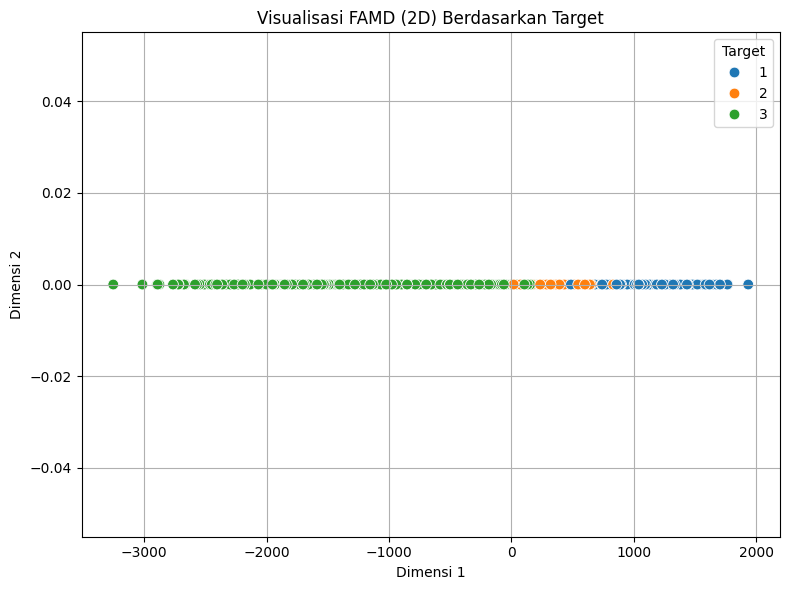

In [40]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=famd_df, x="Dim1", y="Dim2", hue="target", palette="tab10", s=60)

plt.title("Visualisasi FAMD (2D) Berdasarkan Target")
plt.xlabel("Dimensi 1")
plt.ylabel("Dimensi 2")
plt.legend(title="Target")
plt.grid(True)
plt.tight_layout()
plt.show()

Ada beberapa hal tambahan yang kami lakukan dalam tahap preposessing, selain mengaplikasikan suatu hal yang kami pikir terbaik seperti pembuatan fitur baru, kami melakukan beberapa method agar dataset lebih siap untuk diterima model, dan beberapa kesimpulan juga:

1. Stratified Split dengan proporsi 80 : 20
2. FAMD untuk mereduksi dimensi Dataset
3. Fitur yang telah dipilih sudah cukup cocok melihat hasil plot data, bisa dilihat fitur menghasilkan plot data yang terkelompok dan hampir tidak ada label yang tercampur dengan label lain

# **III. Modeling**

## ***A. Model Application***

### 1. Model dengan Class

In [41]:
class KNN:
    def __init__(self, k=5, p=2):
        self.k = k
        self.p= p 

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def minkowski_distance(self, a, b):
        return np.sum(np.abs(a - b) ** self.p) ** (1 / self.p)
    
    def predict(self, X):
        X_test = X
        distances = np.zeros((X_test.shape[0], self.X_train.shape[0]))

        for i, test_point in enumerate(X_test):
            for j, train_point in enumerate(self.X_train):
                distances[i, j] = self.minkowski_distance(test_point, train_point)

        nearest_neighbors_indices = np.argsort(distances, axis=1)[:, :self.k]
        neighbors = np.array(self.y_train)[nearest_neighbors_indices]

        y_pred = []
        for neighbor_classes in neighbors:
            classes, counts = np.unique(neighbor_classes, return_counts=True)
            predicted_class = classes[np.argmax(counts)]
            y_pred.append(predicted_class)

        return np.array(y_pred)
    
    def plot_neighbors(self, input_point, y_train, zoom=False):
        distances = np.array([self.minkowski_distance(input_point, train_point) for train_point in self.X_train])
        nearest_neighbors_indices = np.argsort(distances)[:self.k]

        plt.figure(figsize=(12, 8))
        scatter = plt.scatter(self.X_train[:, 0], self.X_train[:, 1], c=y_train, cmap="coolwarm", alpha=0.7, label="Training Data")
        plt.colorbar(scatter, label="Class")

        plt.scatter(input_point[0], input_point[1], c="yellow", edgecolors="black", s=200, marker="*", label="Input Data")

        cmap = plt.cm.coolwarm
        norm = plt.Normalize(vmin=0, vmax=1)

        for i, idx in enumerate(nearest_neighbors_indices):
            neighbor_point = self.X_train[idx]
            color = cmap(norm(y_train[idx])) 
            label = "Nearest Neighbors" if i == 0 else None
            plt.scatter(neighbor_point[0], neighbor_point[1], facecolors=color, edgecolors="black", 
                        s=150, linewidth=2, label=label)
            plt.plot([input_point[0], neighbor_point[0]], 
                     [input_point[1], neighbor_point[1]], 
                     "black", linestyle="dashed", alpha=0.5)
            plt.text(neighbor_point[0]+0.01, neighbor_point[1]+0.01, f"{i+1}", fontsize=9, color="black")

        plt.xlabel("Dim 1 (FAMD)")
        plt.ylabel("Dim 2 (FAMD)")
        plt.title("FAMD Scatter Plot dengan Input dan K Nearest Neighbors")
        plt.legend()
        plt.grid(True)

        if zoom:
            all_x = [input_point[0]] + [self.X_train[idx][0] for idx in nearest_neighbors_indices]
            all_y = [input_point[1]] + [self.X_train[idx][1] for idx in nearest_neighbors_indices]

            x_padding = (max(all_x) - min(all_x)) * 3.5
            y_padding = (max(all_y) - min(all_y)) * 3.5

            plt.xlim(min(all_x) - x_padding, max(all_x) + x_padding)
            plt.ylim(min(all_y) - y_padding, max(all_y) + y_padding)

            print("Label Tetangga Terdekat:")
            for i, idx in enumerate(nearest_neighbors_indices):
                print(f"Tetangga ke-{i+1}: Label = {y_train[idx]}")

        plt.show()

### 2. Rule of Thumb

In [42]:
rule_of_thumb = round(np.sqrt(len(X_train_famd)))
rule_of_thumb

41

### 3. K Cross Validation 

In [43]:
train_accs = []
test_accs = []
k_values = range(1, 10)

for k in k_values:
    model = KNN(k=k, p=2)
    model.fit(X_train_famd, y_train)
    y_pred_train = model.predict(X_train_famd)
    y_pred_test = model.predict(X_test_famd)

    train_acc = np.mean(y_pred_train == y_train) * 100
    test_acc = np.mean(y_pred_test == y_test) * 100

    train_accs.append(train_acc)
    test_accs.append(test_acc)

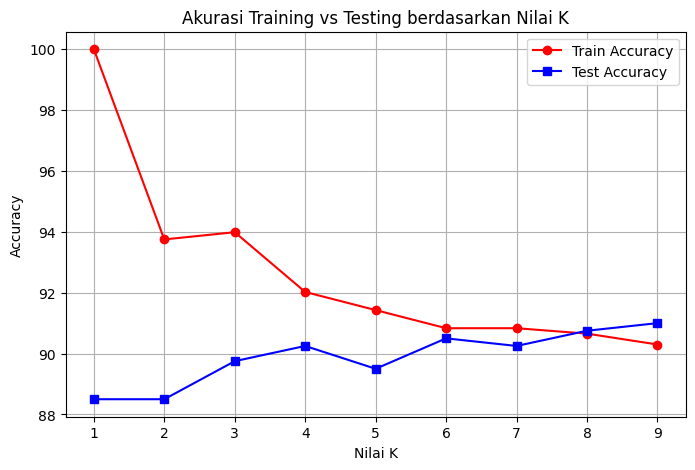

In [44]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, train_accs, marker="o", label="Train Accuracy", color="red")
plt.plot(k_values, test_accs, marker="s", label="Test Accuracy", color="blue")
plt.xlabel("Nilai K")
plt.ylabel("Accuracy")
plt.title("Akurasi Training vs Testing berdasarkan Nilai K")
plt.xticks(k_values)
plt.legend()
plt.grid()
plt.show()

### 4. Elbow Method

In [45]:
def error_rate(y_true, y_pred):
    return np.sum(y_true != y_pred) / len(y_true)

errors = []

for k in k_values:
    model = KNN(k=k, p=2)
    model.fit(X_train_famd, y_train)
    y_pred = model.predict(X_test_famd)
    error = error_rate(y_test, y_pred)
    errors.append(error)

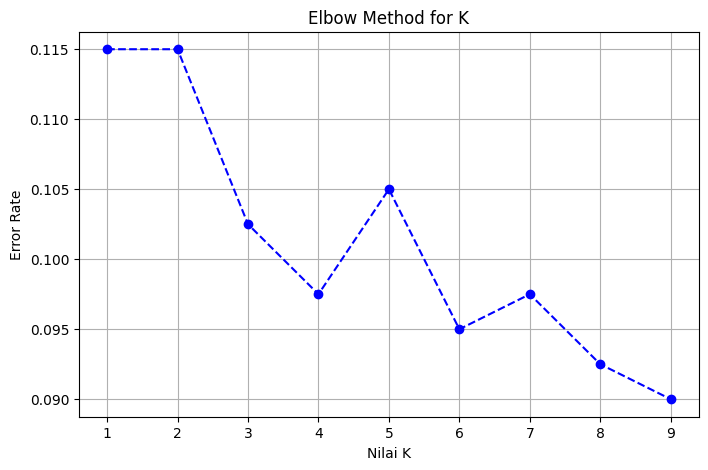

In [46]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, errors, marker="o", linestyle="dashed", color="b")
plt.xlabel("Nilai K")
plt.ylabel("Error Rate")
plt.title("Elbow Method for K")
plt.xticks(k_values)
plt.grid()
plt.show()

### 5. Pengaplikasian Model

In [47]:
model = KNN(k=8, p=2)
model.fit(X_train_famd, y_train)
y_pred_train = model.predict(X_train_famd)
y_pred_test = model.predict(X_test_famd)

## ***B. Hasil Prediksi***

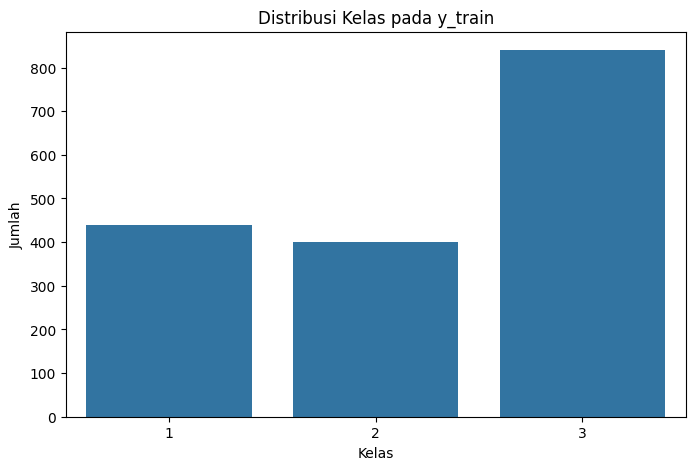

In [48]:
plt.figure(figsize=(8, 5))
sns.countplot(x=y_train)
plt.title("Distribusi Kelas pada y_train")
plt.xlabel("Kelas")
plt.ylabel("Jumlah")
plt.show()

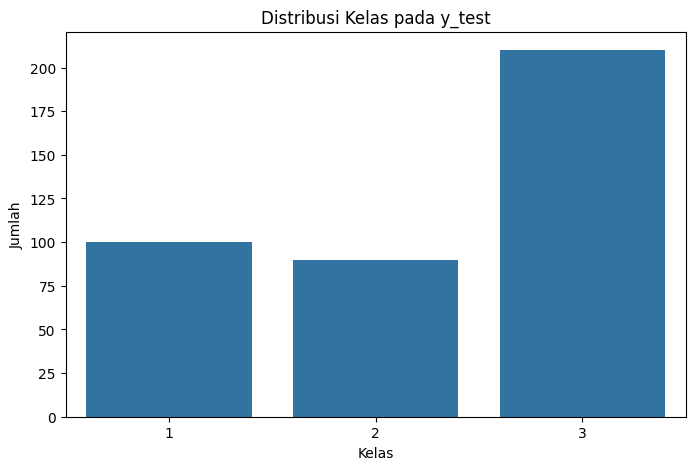

In [49]:
plt.figure(figsize=(8, 5))
sns.countplot(x=y_test)
plt.title("Distribusi Kelas pada y_test")
plt.xlabel("Kelas")
plt.ylabel("Jumlah")
plt.show()

### 1. Training Model

In [50]:
y_pred_train

array([1, 3, 2, ..., 3, 1, 3])

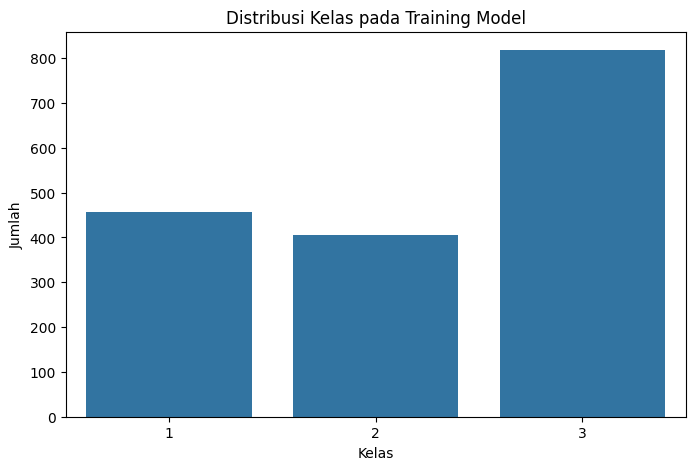

In [51]:
plt.figure(figsize=(8, 5))
sns.countplot(x=y_pred_train)
plt.title("Distribusi Kelas pada Training Model")
plt.xlabel("Kelas")
plt.ylabel("Jumlah")
plt.show()

### 2. Testing Model

In [52]:
y_pred_test

array([2, 2, 1, 1, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 3, 2, 1, 2, 2, 2, 2, 2,
       3, 2, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2,
       2, 2, 2, 2, 3, 2, 1, 1, 1, 2, 2, 3, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 1, 2, 1, 2, 2, 3, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2,
       2, 2, 3, 3, 3, 3, 3, 3, 3, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 3, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 3, 3, 2, 3, 3, 2, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 1,

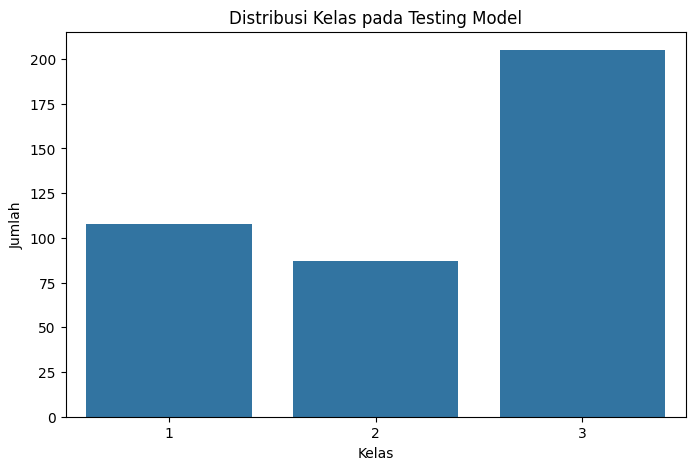

In [53]:
plt.figure(figsize=(8, 5))
sns.countplot(x=y_pred_test)
plt.title("Distribusi Kelas pada Testing Model")
plt.xlabel("Kelas")
plt.ylabel("Jumlah")
plt.show()

## ***C. Visualisasi Model***

### 1. Uji Coba Data Baru

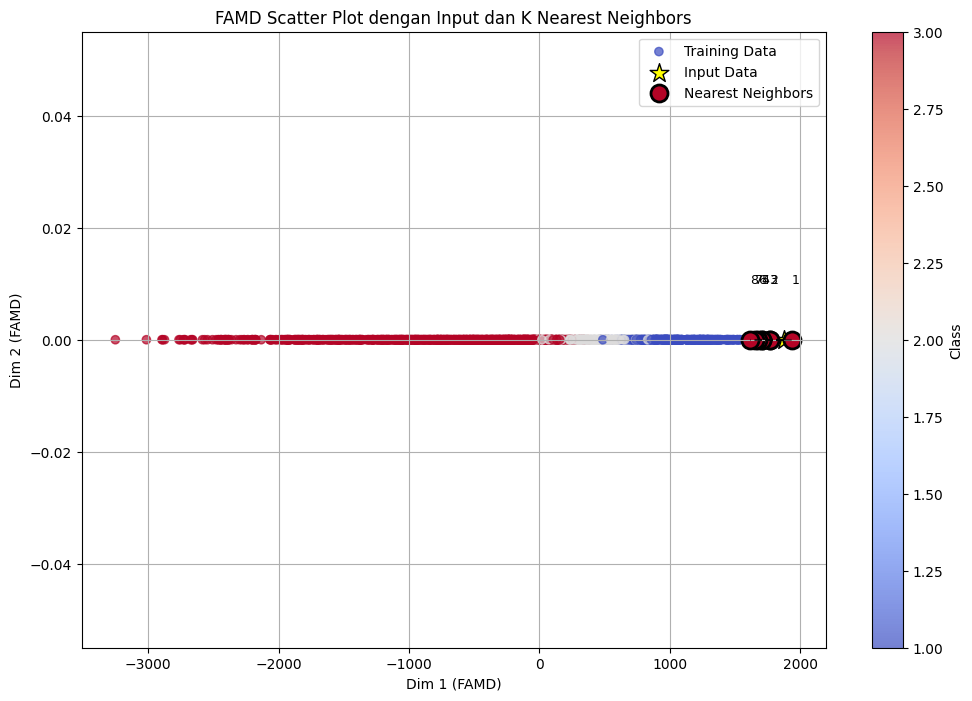

In [54]:
input_data = [900, 18, 3, 2]
input_df = pd.DataFrame([input_data], columns=feature_cols)
input_famd = famd_transform_auto(input_df, famd_model)[0] 
model.plot_neighbors(input_famd, y_train, zoom=False)

C:\Users\nizam\AppData\Local\Temp\ipykernel_17832\3155621337.py:70: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  plt.ylim(min(all_y) - y_padding, max(all_y) + y_padding)


Label Tetangga Terdekat:
Tetangga ke-1: Label = 1
Tetangga ke-2: Label = 1
Tetangga ke-3: Label = 1
Tetangga ke-4: Label = 1
Tetangga ke-5: Label = 1
Tetangga ke-6: Label = 1
Tetangga ke-7: Label = 1
Tetangga ke-8: Label = 1


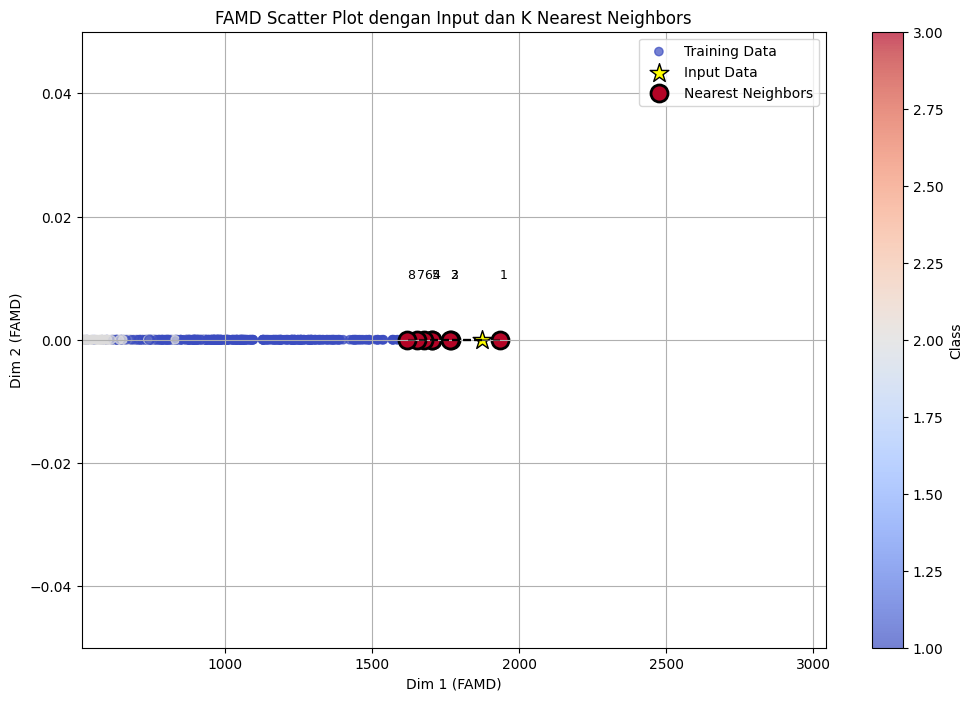

In [55]:
model.plot_neighbors(input_famd, y_train, zoom=True)

### 2. Reverse Encoding untuk Visualsasi

In [56]:
def reverse_mapping(mapping):
    return {v: k for k, v in mapping.items()}

reverse_map_target = reverse_mapping(map_target)
dataset["Target"] = dataset["Target"].map(reverse_map_target)

### 3. Distribusi Hasil Prediksi

In [57]:
data_pred = pd.DataFrame({"Prediksi": y_pred_test, "Aktual": y_test})
data_pred.to_csv("data_pred")
data_pred

,Prediksi,Aktual
0,2,2
1,2,2
2,1,2
3,1,2
4,2,2
...,...,...
395,1,1
396,1,1
397,1,1
398,2,1


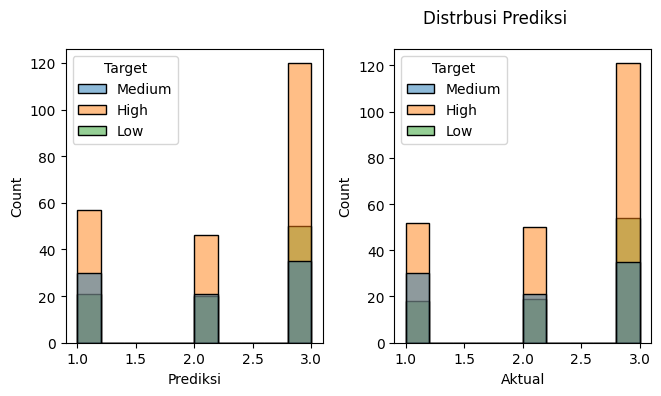

In [58]:
plt.figure(figsize=(10, 4))
for i, col in enumerate(data_pred):
    plt.subplot(1, 3, i+1)
    sns.histplot(x=data_pred[col], hue=dataset['Target'])

plt.suptitle("Distrbusi Prediksi")
plt.tight_layout()
plt.show()

### 4. Confusion Matrix

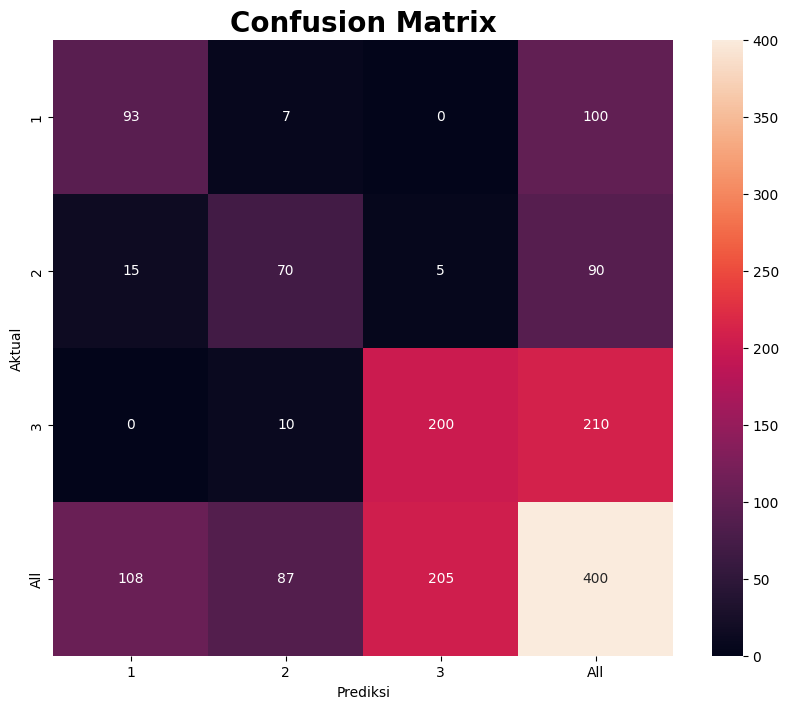

,1,2,3,All
1,93,7,0,100
2,15,70,5,90
3,0,10,200,210
All,108,87,205,400


In [59]:
data_confusion = pd.crosstab(y_test, y_pred_test, margins=True)
data_confusion.columns = data_confusion.columns.tolist()
data_confusion.index = data_confusion.index.tolist()
    
plt.figure(figsize=(10, 8))
plt.title('Confusion Matrix', size=20, weight='bold')
sns.heatmap(data_confusion, annot=True, fmt='d')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

display(data_confusion)

### 5. Analisis Korelasi Fitur dengan Fitur

#### *a. Fitur Numerik*

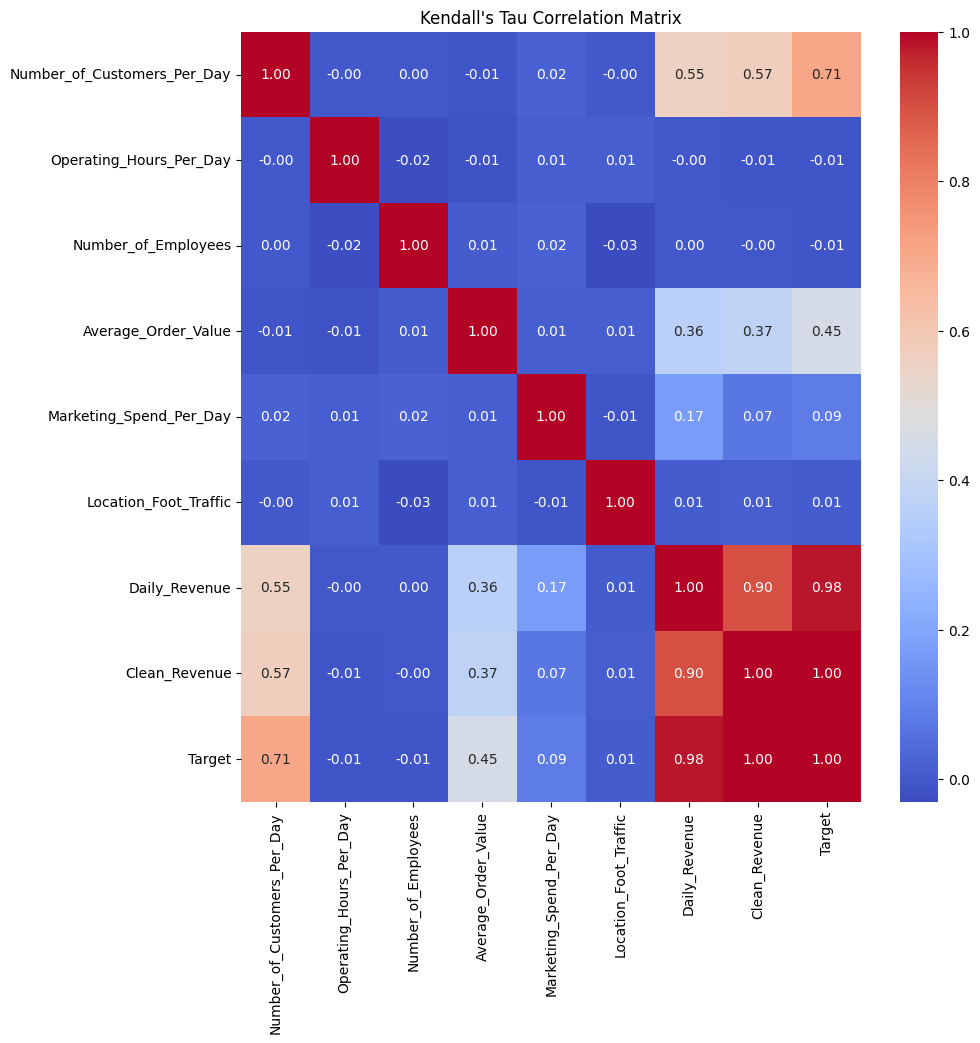

In [60]:
fitur_continu_real
corr_matrix = pd.DataFrame(index=fitur_continu_real, columns=fitur_continu_real)

for col1 in fitur_continu_real:
    for col2 in fitur_continu_real:
        corr_matrix.loc[col1, col2] = kendall_method(dataset_copy[col1].values, dataset_copy[col2].values)

corr_matrix = corr_matrix.astype(float)

plt.figure(figsize=(10,10))
sns.heatmap(corr_matrix, cmap='coolwarm', fmt=".2f", annot=True)
plt.title("Kendall's Tau Correlation Matrix")
plt.show()

## ***D. Evaluasi Model***

### 1. Confusion Matrix

#### *a. Fungsi Confusion Matrix*

In [70]:
def confusion_matrix(y_true, y_pred, average):
    accuracy_array = []
    precision_array = []
    recall_array = []
    f1_array = []

    labels = np.unique(y_true)

    for label in labels:
        TP = np.sum((y_true == label) & (y_pred == label))
        FP = np.sum((y_true != label) & (y_pred == label))

        TN = np.sum((y_true != label) & (y_pred != label))
        FN = np.sum((y_true == label) & (y_pred != label))

        accuracy = (TP + TN) / (TP + TN + FP + FN) if  (TP + TN + FP + FN) != 0 else 0
        precision = TP / (TP + FP) if (TP + FP) != 0 else 0
        recall = TP / (TP + FN) if (TP + FN) != 0 else 0
        f1_score = 2 * (precision * recall) / (precision + recall)

        accuracy_array.append(accuracy)
        precision_array.append(precision)
        recall_array.append(recall)
        f1_array.append(f1_score)

    if average == 'macro':
        accuracy = np.mean(accuracy_array)
        precision = np.mean(precision_array)
        recall = np.mean(recall_array)
        f1_score = np.mean(f1_array)

    elif average == "micro":
        TP = np.sum(y_true == y_pred)
        FP = np.sum((y_true != y_pred) & (y_pred != y_true))

        TN = np.sum(y_true == y_pred)
        FN  = np.sum((y_true == y_pred) & (y_true != y_pred))

        accuracy = (TP + TN) / (TP + TN + FP + FN) if  (TP + TN + FP + FN) != 0 else 0
        precision = TP / (TP + FP) if (TP + FP) != 0 else 0
        recall = TP / (TP + FN) if (TP + FN) != 0 else 0
        f1_score = 2 * (precision * recall) / (precision + recall)
    
    return accuracy, precision, recall, f1_score

#### *b. Evaluasi Training Model*

In [71]:
acccuracy_train, precision_train, recall_train, f1_score_train = confusion_matrix(y_train, y_pred_train, average='macro')
print('-' * 30)
print(f"Akurasi train: {acccuracy_train:.2f}")
print('-' * 30)
print(f"Presisi train: {precision_train:.2f}")
print('-' * 30)
print(f"Recall train: {recall_train:.2f}")
print('-' * 30)
print(f"F1 Score train: {f1_score_train:.2f}")
print('-' * 30)

------------------------------
Akurasi train: 0.94
------------------------------
Presisi train: 0.89
------------------------------
Recall train: 0.89
------------------------------
F1 Score train: 0.89
------------------------------


#### *c. Evaluasi Testing Model*

In [72]:
acccuracy_test, precision_test, recall_test, f1_score_test = confusion_matrix(y_test, y_pred_test, average='macro')
print('-' * 30)
print(f"Akurasi test: {acccuracy_test:.2f}")
print('-' * 30)
print(f"Presisi test: {precision_test:.2f}")
print('-' * 30)
print(f"Recall test: {recall_test:.2f}")
print('-' * 30)
print(f"F1 Score test: {f1_score_test:.2f}")
print('-' * 30)

------------------------------
Akurasi test: 0.94
------------------------------
Presisi test: 0.88
------------------------------
Recall test: 0.89
------------------------------
F1 Score test: 0.88
------------------------------


### 2. Bias dan Variance Model

In [73]:
bias_knn = 1 - acccuracy_test
variance_knn = acccuracy_train - acccuracy_test

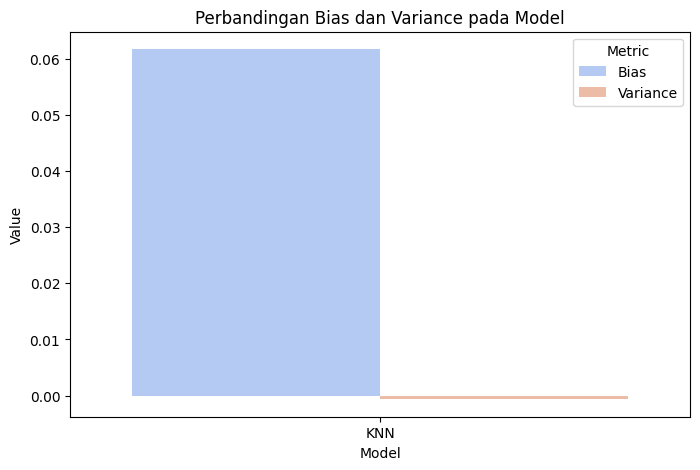

In [74]:
data = {
    "Model": ["KNN", "KNN"],
    "Metric": ["Bias", "Variance"],
    "Value": [bias_knn, variance_knn]
}
df = pd.DataFrame(data)

plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="Model", y="Value", hue="Metric", palette="coolwarm")

plt.xlabel("Model")
plt.ylabel("Value")
plt.title("Perbandingan Bias dan Variance pada Model")
plt.legend(title="Metric")

plt.show()

### 3. K-Fold Cross Validation

#### *a. Fungsi K-Fold*

In [75]:
def stratified_k_fold(X, y, model, k = 7):

    unique_classes, counts = np.unique(y, return_counts=True)
    class_indices = {cls: np.where(y == cls)[0] for cls in unique_classes}
    folds = [[] for _ in range(k)]

    for cls, indices in class_indices.items():
        np.random.shuffle(indices)
        fold_sizes = np.array_split(indices, k)
        for i in range(k):
            folds[i].extend(fold_sizes[i])

    accuracies = []

    for i in range(k):
        train_idx = np.hstack([[j] for j in range(k) if j != i])
        test_idx = np.array(folds[i])

        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        accuracy, _, _, _ = confusion_matrix(y_test, y_pred, average='macro')
        accuracies.append(accuracy)

        print(f"Fold: {i + 1} | Accuracy: {accuracy}")
    
    avg_acc = np.mean(accuracies)
    std_dev = np.std(accuracies)

    print(f"Average Accuracy Between Folds: {avg_acc}")
    print(f"Total Standard Deviation: {std_dev}")

    return avg_acc, std_dev

#### *b. Model K-Fold*

In [76]:
k_fold = stratified_k_fold(X_test_famd, y_test, model, k=8)

Fold: 1 | Accuracy: 0.4871794871794872
Fold: 2 | Accuracy: 0.4871794871794872
Fold: 3 | Accuracy: 0.48
Fold: 4 | Accuracy: 0.48
Fold: 5 | Accuracy: 0.4829931972789116
Fold: 6 | Accuracy: 0.4829931972789116
Fold: 7 | Accuracy: 0.4829931972789116
Fold: 8 | Accuracy: 0.4829931972789116
Average Accuracy Between Folds: 0.48329147043432763
Total Standard Deviation: 0.0025557966263563556


C:\Users\nizam\AppData\Local\Temp\ipykernel_17832\2303464333.py:19: RuntimeWarning: invalid value encountered in scalar divide
  f1_score = 2 * (precision * recall) / (precision + recall)
C:\Users\nizam\AppData\Local\Temp\ipykernel_17832\2303464333.py:19: RuntimeWarning: invalid value encountered in scalar divide
  f1_score = 2 * (precision * recall) / (precision + recall)
C:\Users\nizam\AppData\Local\Temp\ipykernel_17832\2303464333.py:19: RuntimeWarning: invalid value encountered in scalar divide
  f1_score = 2 * (precision * recall) / (precision + recall)
C:\Users\nizam\AppData\Local\Temp\ipykernel_17832\2303464333.py:19: RuntimeWarning: invalid value encountered in scalar divide
  f1_score = 2 * (precision * recall) / (precision + recall)
C:\Users\nizam\AppData\Local\Temp\ipykernel_17832\2303464333.py:19: RuntimeWarning: invalid value encountered in scalar divide
  f1_score = 2 * (precision * recall) / (precision + recall)
C:\Users\nizam\AppData\Local\Temp\ipykernel_17832\2303464333

## **IV. Final Evaluation**

Berbagai proses telah dilakukan dan berikut beberapa hal yang bisa kami tarik sebagai kesimpulan:

1. Model KNN sudah bisa memberikan hasil prediksi yang konsisten dan akurat, namun jika dimasukkan data baru yang diluar dataset, model masihkurang mampu untuk menghasilkan prediksi yang baik

2. Faktor yang mempengaruhi revenue suatu coffee shop adalah Jumlah Customer per hari, berapa budget marketing yang dikeluarkan, berapa transaksi yang dihasilkan pelanggan dan berapa revenue yang didaptkan tiap hari

3. Marketing belum tentu menarik pelanggan yang banyak, namun tetap menentukan revenue suatu coffee shop

4. Penghasilan Kotor tidak terlalu mengubah / megurangi penghasilan bersih perbulannya.

---

saran yang bisa kami berikan:

1. Untuk coffee shop owner hal yang paling mempengaruhi berapa banyak pelanggan yang datang ke coffee shop anda, belum bisa ditentukan dari marketing, namun berapa banyak budget yang dikeluarkan dalam marketing tetap menentukan penghasilan yang anda dapatkan.

2. Kemungkinan besar, pencinta kopi di daerah tersebut lebih berpatok kepada selera masing masing (entah itu kopi ataupun toko kopi yang didatangi) karena mereka tidak terlalu berpengaruh terhadap marketing yang diberikan.

3. Bidang wirausaha coffee shop disana berkembang dengan pesat, terbukti dari hasil dari setiap toko yang kebanyakn memiliki revenue yang tinggi
